In [130]:
import os
import sys
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.io as sio
import scanpy.external as sce
import matplotlib.pyplot as plt
import re
import anndata as ad
import statistics
import torch
import scvi
import cosg
import celltypist
import tempfile
import sklearn
import mudata as md
import muon as mu
md.set_options(pull_on_update=False)
import muon
import decoupler as dc
from datetime import datetime
from scib_metrics.benchmark import Benchmarker
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
from multiprocessing import Pool
import uuid
scvi.settings.num_threads = 16
scvi.settings.seed = 0
sc._settings.n_jobs=16
sc.settings.verbosity = 4
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='png')
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)

Seed set to 0


In [ ]:
Classification = sys.argv[1]
dataset = sys.argv[2]
groupby = sys.argv[3]

In [132]:
Classification='Classification_L3'
dataset='Cytotoxic_CD4pos_T_cells'
groupby='Classification_L4'

In [133]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [134]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [135]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [136]:
if os.path.exists(f"{obj_path}/{dataset}_indices_labels_umap.csv"):
    indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)
else:
    indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels.csv",index_col=0)

In [137]:
indices = indices[['Classification_L4','Classification_L3','Classification_L2','Classification_L1',
                   'leiden_cluster','UMAP_1','UMAP_2']]

In [138]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [139]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch']
    if 'Classification_L4' not in adt.obs.columns:
        adt.obs = adt.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [140]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical
... storing 'leiden_cluster' as categorical


In [141]:
adt.strings_to_categoricals()

# 1. Load latent representation and umap coords

In [154]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

In [143]:
if not os.path.exists(f"{obj_path}/umap_{dataset}_{groupby}.png"):
    sc.pl.umap(
    adata,
    color=groupby,
    legend_fontsize=3,ncols=3,frameon=False,
    size=0.05,
    save=f'_{dataset}_{groupby}',show=False
    )

# 2. Maker Genes by using FindAllMarkers roc and count

In [144]:
# downsample_adata for seurat
if adata.n_obs > 100000:
    cell_indices = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 100000,
                                                     by = groupby,random_state=0)
    adata_sampled = adata[cell_indices].copy()
else:
    adata_sampled = adata.copy()

In [145]:
adata_sampled.layers['count'] = adata_sampled.X.copy()
sc.pp.normalize_total(adata_sampled, target_sum=1e4)
sc.pp.log1p(adata_sampled)

normalizing counts per cell
    finished (0:00:00)


In [146]:
#for python
if len(adata.obs[groupby].unique())>1:
    adata_sampled.write(f"{obj_path}{dataset}_tmp.h5ad")
    os.system(f"Rscript /home/liyanguo/MyImmuCell/00_code_MyImmuCell/1_annotation/DEG_ROC.R {obj_path} {dataset} {groupby}")
    os.system(f"rm {obj_path}{dataset}_tmp.h5ad")

sh: 1: Rscript: not found


# 3. Maker Genes cosg

In [147]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:01)


In [148]:
sc.pp.log1p(adata)

In [149]:
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=100,n_genes_user=100,remove_lowly_expressed=True,expressed_pct=0.1,
          )

In [150]:
xlsx = pd.ExcelWriter(f"{obj_path}cosg_genes_{dataset}_{groupby}.xlsx")
pd.DataFrame(adata.uns[f'cosg_{groupby}']['names']).to_excel(xlsx,sheet_name='names')
pd.DataFrame(adata.uns[f'cosg_{groupby}']['scores']).to_excel(xlsx,sheet_name='scores')
xlsx.close()

# 4. Maker Genes GSEA

In [156]:
moncao = pd.read_excel("/home/liyanguo/Marker/Moncao_immune_cell_dataset.xlsx",sheet_name='FoldChange TPM')

In [157]:
moncao.columns = moncao.columns.str.replace('/', '_', regex=True)

In [158]:
del moncao['Ensembl ID']
del moncao['Entrez ID']

In [159]:
resource = pd.DataFrame(columns=['source', 'target',  'weight'])
for cell_type in moncao.columns[1:]:
    temp_df = moncao[['Gene name', cell_type]].copy()
    temp_df.columns = ['target', 'weight']
    temp_df['source'] = cell_type
    resource = pd.concat([resource, temp_df],ignore_index=True)

In [160]:
resource = resource.drop_duplicates(subset=['source', 'target'])

In [161]:
dc.mt.ulm(data=adata, net=resource)

In [162]:
score = dc.pp.get_obsm(adata, key='score_ulm')

computing PCA
    with n_comps=50
    finished (0:00:06)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])
Storing dendrogram info using `.uns['dendrogram_Classification_L4']`


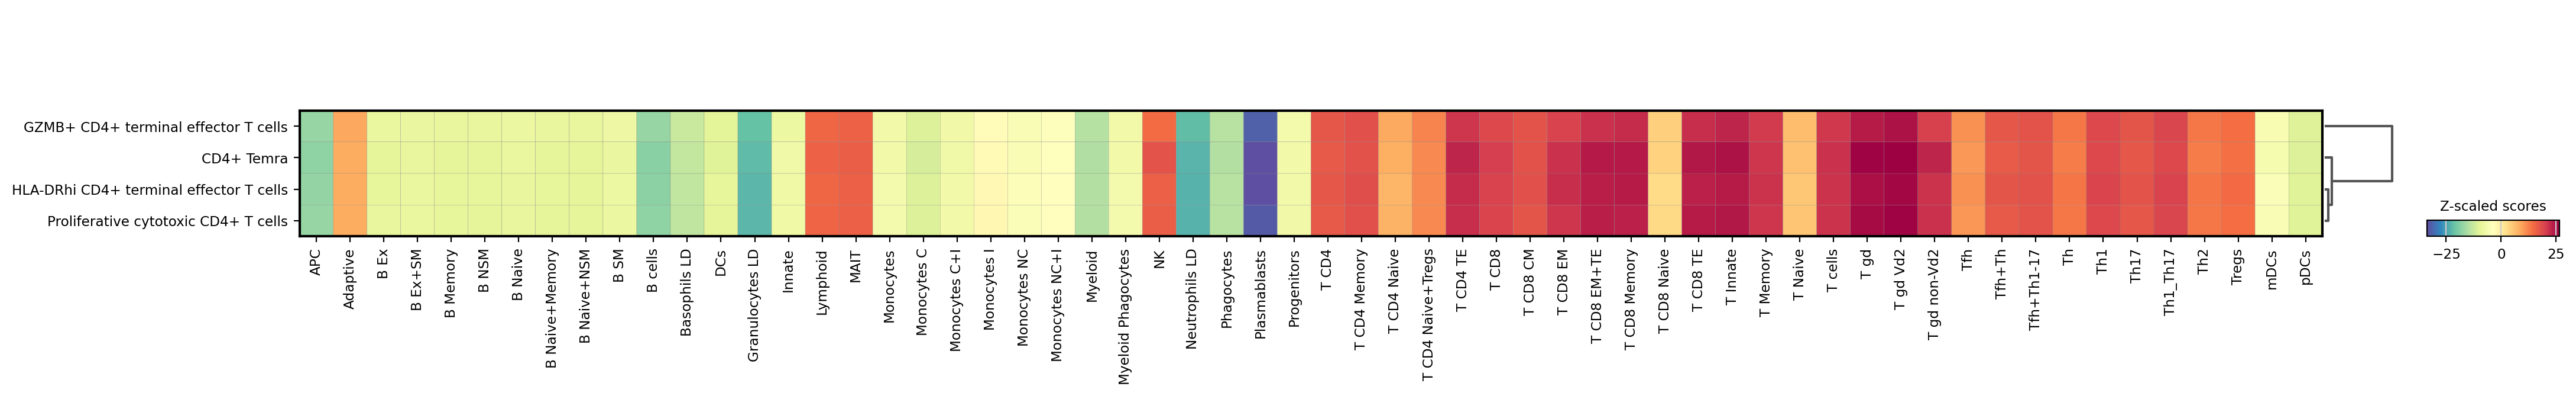

In [163]:
sc.pl.matrixplot(
    adata=score,
    var_names=score.var_names,
    groupby='Classification_L4',
    dendrogram=True,
    colorbar_title='Z-scaled scores',
    cmap='Spectral_r',
    save=f'{dataset}_{groupby}.png',
)

# 5. Process adt

In [164]:
adt.obsm['X_umap'] = adata.obsm['X_umap']

In [165]:
adt.X.max()

np.float32(1235.0)

In [166]:
if "clr" not in adt.layers:
    adt.layers["clr"] = mu.prot.pp.clr(adt,inplace= False).X.copy()

In [167]:
adt_dict={
    "CD45RA": ["CD45RA"],
    
    'B': ['IgD','IgM',"CD19",'CD27','CD137'],
    
    "ILC|NK|NKT|γδ T|": ["CD56","CD161",'CD16',],
    
    "T": ["CD3","CD4","CD8",'CD27','CD28','CD134','CD272'],
    "Naive/Memory T": ["CD45RA","CD127","CD62L",'CD197',],
    "Treg":['CD25','CD137','CD357',],
    "Th1|ILC":["CD183",'CD186','CD366'],
    "Th17|ILC":['CD161','CD196',],
    "Tfh|ILC|Effector":['CD185','CD278','CD279',],

    'DC':['CD11c','HLA-DR',"CD183",'CD197'],

    'Monocytes':['CD14','CD16'],
}

In [168]:
sc.pl.dotplot(
adt,
groupby=groupby,
var_names=adt_dict,
save=f"{dataset}_{groupby}_scADT_TOTALVI_clr",layer='clr',
expression_cutoff=1,
dot_min=0.1,
show=False,
)

{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

In [169]:
adt.write(f"{obj_path}{dataset}_scADT_count.h5ad",compression="gzip")

In [170]:
import session_info
session_info.show()

In [ ]:
nohup python 27E_CITEseq_TOTALVI_marker_subset.py Classification_other Th17 Classification_L4 &
nohup python 27E_CITEseq_TOTALVI_marker_subset.py Classification_other Th1 Classification_L4 &

In [ ]:
nohup python 27E_CITEseq_TOTALVI_marker_subset.py Classification_L3 Cytotoxic_CD4pos_T_cells Classification_L4